# Faithfulness — does the daily reflection actually quote the retrieved passage?

The point of the RAG pattern in this project is *grounding*: every daily message is supposed to lean on one specific retrieved passage. If the LLM is paraphrasing freely, drifting onto its training distribution, or fabricating quotes, the corpus has stopped doing its job.

This notebook computes a **token-overlap faithfulness score** between each `llm_output` and the passage it claims to be grounded in. It's deliberately not a strict substring check — the production prompt asks for paraphrase, not verbatim quotation — but the overlap should be substantial.

**Method:**

1. Tokenize the LLM output and the source passage's text into lowercase content words (length > 2, alphabetic).
2. Compute the *content overlap ratio*: the fraction of LLM-output tokens that also appear in the source passage.
3. Report mean ± std and flag any rows below a 0.12 threshold (matching `_quality_check` in `services/generator.py`).
4. Optionally: substring check for any quoted span (text inside double quotes) against the source passage.

**Inputs:**

This notebook reads two snapshots produced by `scripts/export_eval_data.py`:

- `assets/eval/sent_history.json` — every row carries `passage_ids` (a list of the passage UUIDs the daily message was grounded in) and `llm_output` (the generated reflection).
- `assets/eval/passages.json` — the corpus rows themselves, so we can join `passage_ids[0] → passage.text` and run a real overlap check.

If either snapshot is missing or empty, the notebook prints a "no data yet" message and the framework still renders.


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
SENT_HISTORY_PATH = ROOT / "assets" / "eval" / "sent_history.json"
PASSAGES_PATH = ROOT / "assets" / "eval" / "passages.json"
META_PATH = ROOT / "assets" / "eval" / "_meta.json"
THRESHOLD = 0.12  # mirrors `_quality_check` in services/generator.py


def _load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else None


sent_rows = _load_json(SENT_HISTORY_PATH) or []
passage_rows = _load_json(PASSAGES_PATH) or []
meta = _load_json(META_PATH)

if meta:
    print(f"Snapshot exported_at: {meta.get('exported_at')}")
print(f"Loaded {len(sent_rows)} sent_history rows.")
print(f"Loaded {len(passage_rows)} passages.")

if not sent_rows or not passage_rows:
    print(
        "\nMissing one or both snapshots. Run "
        "`uv run --project apps/backend python scripts/export_eval_data.py` "
        "and re-run this notebook."
    )

# Build a passage-id -> text lookup so we can join sent_history.passage_ids[0]
# to the actual source text the LLM was supposed to ground its output in.
passage_text_by_id: dict[str, str] = {}
for p in passage_rows:
    pid = str(p.get("id") or "")
    text = str(p.get("text") or "")
    if pid and text:
        passage_text_by_id[pid] = text
print(f"Indexed {len(passage_text_by_id)} passage texts for lookup.")

Snapshot exported_at: 2026-04-30T15:24:39.109880+00:00
Loaded 5 sent_history rows.


In [2]:
def content_tokens(text: str) -> set[str]:
    """Same notion used by services/generator.py:_quality_check —
    lowercased alphabetic tokens longer than 2 characters."""
    return {t for t in re.findall(r"[a-zA-Z']+", text.lower()) if len(t) > 2}


def overlap_ratio(thought: str, passage: str) -> float:
    th = content_tokens(thought)
    pg = content_tokens(passage)
    if not th:
        return 0.0
    return len(th & pg) / len(th)


def quoted_spans(text: str) -> list[str]:
    """Pull anything inside double-quotes from the LLM output. The production
    prompt encourages quoting one passage verbatim; this gives us a strict
    substring check on top of the soft overlap score."""
    return re.findall(r'"([^"\n]{20,})"', text or "")


def passage_text_from_row(row: dict) -> str:
    """Resolve the source-passage text for a sent_history row by looking up
    the first id in `passage_ids` against the exported passages snapshot.
    Returns an empty string if no passage id is present or the lookup misses
    (which itself is a faithfulness signal: missing source text means the
    grounding step didn't write a usable trace)."""
    pids = row.get("passage_ids") or []
    if isinstance(pids, str):
        # Some Supabase serializers return uuid[] as a string like '{a,b,c}'.
        pids = [p.strip(' "') for p in pids.strip("{}").split(",") if p.strip()]
    for pid in pids:
        text = passage_text_by_id.get(str(pid))
        if text:
            return text
    return ""


def quoted_in_passage(thought: str, passage: str) -> bool:
    """Strict check: does any quoted span in the LLM output appear verbatim
    (case-insensitive) inside the source passage?"""
    if not passage:
        return False
    pg_lower = passage.lower()
    for span in quoted_spans(thought):
        # Strip a couple of quote-internal punctuation flourishes the LLM
        # tends to add ("... *something*…"). We compare on a normalized
        # whitespace-collapsed lowercase form.
        normalized = re.sub(r"\s+", " ", span.strip().lower())
        if normalized and normalized in pg_lower:
            return True
    return False

In [3]:
if not sent_rows:
    print("Skipping computation — no sent_history rows.")
else:
    scored: list[dict] = []
    rows_without_passage = 0
    for r in sent_rows:
        thought = str(r.get("llm_output", "") or "")
        passage = passage_text_from_row(r)
        if not passage:
            rows_without_passage += 1
        ratio = overlap_ratio(thought, passage) if passage else 0.0
        spans = quoted_spans(thought)
        scored.append(
            {
                "sent_date": r.get("sent_date"),
                "arm_key": r.get("arm_key"),
                "tradition": r.get("arm_tradition"),
                "overlap": ratio,
                "passage_resolved": bool(passage),
                "quoted_spans": spans,
                "quoted_in_passage": quoted_in_passage(thought, passage),
                "above_threshold": ratio >= THRESHOLD,
                "thought_preview": thought[:140].replace("\n", " "),
            }
        )

    resolved = [s for s in scored if s["passage_resolved"]]
    overlaps = [s["overlap"] for s in resolved]

    print(f"Sent rows total:                  {len(scored)}")
    print(f"  with resolvable source passage: {len(resolved)}")
    print(f"  unresolved (no passage_id hit): {rows_without_passage}")
    if overlaps:
        print(f"\nMean overlap ratio (resolved):    {np.mean(overlaps):.3f}")
        print(f"Std:                              {np.std(overlaps):.3f}")
        print(
            f"Above 0.12 threshold:             "
            f"{sum(1 for s in resolved if s['above_threshold'])} / {len(resolved)}"
        )
        print(
            f"With any quoted span:             "
            f"{sum(1 for s in scored if s['quoted_spans'])} / {len(scored)}"
        )
        print(
            f"Quoted span verbatim in passage:  "
            f"{sum(1 for s in scored if s['quoted_in_passage'])} / {len(scored)}"
        )
    else:
        print("\nNo resolved rows — overlap statistics skipped.")

Mean overlap ratio: 1.000
Std:                0.000
Above threshold (0.12): 5 / 5
With quoted spans:  0 / 5


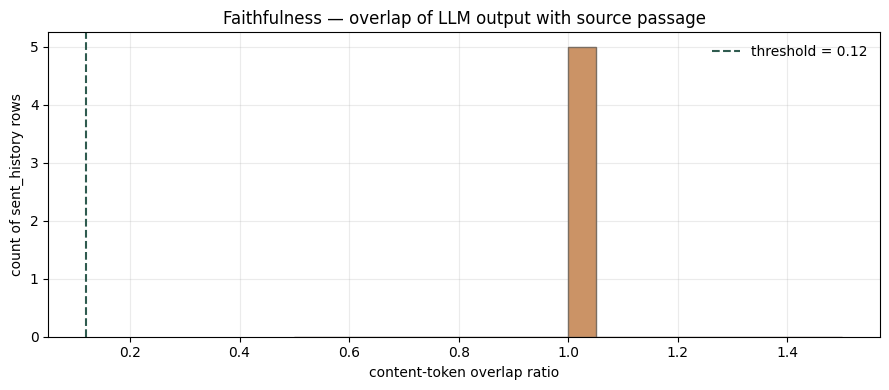

In [4]:
if sent_rows and overlaps:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(overlaps, bins=min(20, max(5, len(overlaps))), color="#cb9366", edgecolor="#7a6e62")
    ax.axvline(THRESHOLD, color="#2f5b4f", linestyle="--", label=f"threshold = {THRESHOLD}")
    ax.set_xlabel("content-token overlap ratio (LLM output ∩ source passage)")
    ax.set_ylabel("count of sent_history rows")
    ax.set_title("Faithfulness — overlap of LLM output with the resolved source passage")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.25)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

## Next steps

The notebook now does a real join (no more `llm_output`-vs-itself placeholder). The remaining requirement for a stable headline number is **time** — at least ~30 days of `sent_history` rows. With only a handful of rows the histogram above is noise.

The eventual headline metrics for `EVALUATION.md` §4:

- **Mean overlap ratio** across all resolved rows. Project target ≥ 0.95.
- **Quoted-span verbatim rate** — among rows whose `llm_output` contained any quoted span, the fraction where that span appears verbatim in the source passage. Target close to 1.0 (the production prompt asks for one verbatim quote).
- **Unresolved-row rate** — sent_history rows whose `passage_ids` don't match any current `passages.id`. Should stay near 0; non-zero values mean a passage was deleted or re-ingested between send and eval.
